# Ноутбук с моделью

## Импортируем необходимые пакеты

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import dill

## Считываем данные в dataframe

In [2]:
df = pd.read_pickle('final/ga_hits-002.pkl')
print(df.shape)
df.head()

(15726470, 11)


,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,None
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,None
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,None
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,None
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,None


In [3]:
df_sessions = pd.read_pickle('final/ga_sessions.pkl')
print(df.shape)
df_sessions.head()

(15726470, 11)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


## Изучаем датасет

In [4]:
df_sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      object 
 1   hit_date        object 
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        object 
 5   hit_referer     object 
 6   hit_page_path   object 
 7   event_category  object 
 8   event_action    object 
 9   event_label     object 
 10  event_value     object 
dtypes: float64(1), int64(1), object(9)
memory usage: 1.3+ GB


In [6]:
df_clean = df_sessions.copy()
missing_values = ((df_clean.isna().sum() / len(df)) * 100).sort_values(ascending=False)
print("Процент пропущенных значений")
missing_values

Процент пропущенных значений


device_model                11.723572
utm_keyword                  6.880508
device_os                    6.804693
utm_adcontent                2.134077
utm_campaign                 1.396391
device_brand                 0.754639
utm_source                   0.000617
session_id                   0.000000
client_id                    0.000000
visit_number                 0.000000
utm_medium                   0.000000
visit_date                   0.000000
visit_time                   0.000000
device_category              0.000000
device_screen_resolution     0.000000
device_browser               0.000000
geo_country                  0.000000
geo_city                     0.000000
dtype: float64

In [7]:
df_clean2 = df.copy()
missing_values2 = ((df_clean2.isna().sum() / len(df)) * 100).sort_values(ascending=False)
print("Процент пропущенных значений")
missing_values2

Процент пропущенных значений


event_value       100.000000
hit_time           58.247795
hit_referer        39.899634
event_label        23.909905
session_id          0.000000
hit_date            0.000000
hit_number          0.000000
hit_page_path       0.000000
hit_type            0.000000
event_action        0.000000
event_category      0.000000
dtype: float64

## Подготовка данных

In [8]:
# Удаляем ненужные атрибуты
drop_cols = ['client_id', 'visit_date', 'visit_time', 'device_model', 'device_screen_resolution', 'geo_country']
df_sessions_clean = df_clean.drop(columns=drop_cols, errors='ignore').copy()

In [9]:
# Удаляем полные дубликаты строк, если они есть
df_sessions_clean = df_sessions_clean.drop_duplicates()

In [10]:
# Удаляем строки с пропущенными значениями
columns = ['utm_keyword', 'device_os', 'utm_adcontent', 'utm_campaign', 'device_brand', 'utm_source']
df_sessions_clean = df_sessions_clean.dropna(subset=columns)

In [11]:
# Убедимся, что пропущенных значений больше нет
df_sessions_clean.isnull().sum()

session_id         0
visit_number       0
utm_source         0
utm_medium         0
utm_campaign       0
utm_adcontent      0
utm_keyword        0
device_category    0
device_os          0
device_brand       0
device_browser     0
geo_city           0
dtype: int64

In [12]:
# Делаем тоже самое со вторым датафреймом
drop_cols2 = ['event_value', 'hit_time', 'hit_date', 'hit_referer']
df_hits_clean = df_clean2.drop(columns=drop_cols2, errors='ignore').copy()
df_huts_clean = df_hits_clean.drop_duplicates()
df_hits_clean.isnull().sum()

session_id              0
hit_number              0
hit_type                0
hit_page_path           0
event_category          0
event_action            0
event_label       3760184
dtype: int64

In [13]:
df_hits_clean.event_label.describe()

count                 11966286
unique                   39825
top       KclpemfoHstknWHFiLit
freq                   6505447
Name: event_label, dtype: object

In [14]:
# Отдельно обрабатываем колонку 'event_label'
df_hits_clean['event_label'] = df_hits_clean['event_label'].fillna('unknown')

In [15]:
df_hits_clean.isnull().sum()

session_id        0
hit_number        0
hit_type          0
hit_page_path     0
event_category    0
event_action      0
event_label       0
dtype: int64

In [16]:
# Выделяем целевую переменную (таргет)
target_actions = [
    'sub_car_claim_click', 'sub_car_claim_submit_click',
    'sub_open_dialog_click', 'sub_custom_question_submit_click',
    'sub_call_number_click', 'sub_callback_submit_click', 
    'sub_submit_success', 'sub_car_request_submit_click'
]
df_hits_clean['is_target'] = df_hits_clean['event_action'].isin(target_actions).astype(int)

In [17]:
# Группируем хиты по session_id, чтобы получить ОДНУ строку на один визит
df_hits_grouped = df_hits_clean.groupby('session_id').agg({
    'is_target': 'max',
    'hit_number': 'max',
    'hit_page_path': 'first',      # берем первую посещенную страницу
    'event_category': 'first',     # берем категорию первого действия
    'event_label': 'first'         # берем тег первого действия
}).reset_index()
print(df_hits_grouped.head())

                                  session_id  is_target  hit_number  \
0  1000009318903347362.1632663668.1632663668          0          15   
1  1000010177899156286.1635013443.1635013443          0          12   
2  1000013386240115915.1635402956.1635402956          0          17   
3  1000017303238376207.1623489300.1623489300          0          18   
4  1000020580299877109.1624943350.1624943350          0           3   

                                       hit_page_path event_category  \
0  podpiska.sberauto.com/faq?utm_source_initial=y...  sub_page_view   
1                             podpiska.sberauto.com/  sub_page_view   
2  sberauto.com/cars/all/lada-vaz/vesta/2fc745ed?...       card_web   
3                             podpiska.sberauto.com/  sub_page_view   
4  sberauto.com/cars/https://sberauto.com/cars/b8...           quiz   

            event_label  
0  KclpemfoHstknWHFiLit  
1               unknown  
2               unknown  
3  KclpemfoHstknWHFiLit  
4  KclpemfoHstkn

## Объединяем два dataframe

In [18]:
df_merged = pd.merge(df_sessions_clean, df_hits_grouped, on='session_id', how='left')
df_merged['is_target'] = df_merged['is_target'].fillna(0).astype(int)
print(df_merged.shape)
df_merged.head()

(578427, 17)


,session_id,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_browser,geo_city,is_target,hit_number,hit_page_path,event_category,event_label
0,9055434745589932991.1637753792.1637753792,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,Chrome,Zlatoust,0,4.0,podpiska.sberauto.com/,sub_page_view,unknown
1,905544597018549464.1636867290.1636867290,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,Samsung Internet,Moscow,0,3.0,podpiska.sberauto.com/,sub_page_view,unknown
2,9055446045651783499.1640648526.1640648526,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,Chrome,Krasnoyarsk,0,20.0,sberauto.com/cars?utm_source_initial=sbol&utm_...,search_form,KWTCzSIXzoqUWjfUQMgP
3,9055455318486370642.1640843788.1640843788,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,LcGIUNPUAmXtQJaDfFBR,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,YaBrowser,Saint Petersburg,0,8.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,unknown
4,9055462349345527315.1638536723.1638536723,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,Safari,Moscow,0,18.0,podpiska.sberauto.com/,sub_page_view,unknown


In [19]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 578427 entries, 0 to 578426
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   session_id       578427 non-null  object 
 1   visit_number     578427 non-null  int64  
 2   utm_source       578427 non-null  object 
 3   utm_medium       578427 non-null  object 
 4   utm_campaign     578427 non-null  object 
 5   utm_adcontent    578427 non-null  object 
 6   utm_keyword      578427 non-null  object 
 7   device_category  578427 non-null  object 
 8   device_os        578427 non-null  object 
 9   device_brand     578427 non-null  object 
 10  device_browser   578427 non-null  object 
 11  geo_city         578427 non-null  object 
 12  is_target        578427 non-null  int64  
 13  hit_number       529450 non-null  float64
 14  hit_page_path    529450 non-null  object 
 15  event_category   529450 non-null  object 
 16  event_label      529450 non-null  obje

In [20]:
# Заполняем пропуски, появившиеся после объединения таблиц
df_merged['hit_number'] = df_merged['hit_number'].fillna(0)
df_merged['hit_page_path'] = df_merged['hit_page_path'].fillna('unknown')
df_merged['event_category'] = df_merged['event_category'].fillna('unknown')
df_merged['event_label'] = df_merged['event_label'].fillna('unknown')

In [21]:
# Удаляем колонку 'session_id'
df_merged = df_merged.drop(columns=['session_id'], errors='ignore')

In [22]:
# Смотрим на описание числовых признаков
df_merged[['visit_number', 'hit_number']].describe()

,visit_number,hit_number
count,578427.000000,578427.000000
mean,1.545739,12.213387
std,4.122506,17.421497
min,1.000000,0.000000
25%,1.000000,3.000000
50%,1.000000,6.000000
75%,1.000000,16.000000
max,228.000000,500.000000


## Feature Engineering

In [23]:
# Разделим пользователей на тех, кто пришел сам и тех кто перешел по платной рекламе
# Фича: 1 — пришел сам, 0 — пришел по платной рекламе
organic_mediums = ['organic', 'referral', '(none)']
df_merged['is_organic'] = df_merged['utm_medium'].isin(organic_mediums).astype(int)

In [24]:
# Определяем топ-3 города по частоте в датасете
top_cities = df_merged['geo_city'].value_counts().head(3).index.tolist()
# Фича: 1 — житель мегаполиса из топа, 0 — другой город
df_merged['is_major_city'] = df_merged['geo_city'].isin(top_cities).astype(int)

In [25]:
# Сколько кликов в среднем делает пользователь за один визит
df_merged['clicks_per_visit'] = df_merged['hit_number'] / (df_merged['visit_number'] + 1e-5)

## Преобразование категориальных переменных

In [26]:
# Кодируем категориальные фичи с помощью OneHotEncoder
columns_to_encode = ['utm_medium', 'device_category', 'device_os', 'device_browser']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(df_merged[columns_to_encode])

feature_names = encoder.get_feature_names_out(columns_to_encode)
df_merged.loc[:, feature_names] = encoder.transform(df_merged[columns_to_encode])

## Масштабируем числовые фичи

In [27]:
scaler = StandardScaler()

numerical_cols = ['visit_number', 'hit_number', 'is_organic', 'is_major_city', 'clicks_per_visit']

scaled_cols = [f"{col}_scaled" for col in numerical_cols]
df_merged[scaled_cols] = scaler.fit_transform(df_merged[numerical_cols])

## Сохраняем датафрейм для этапа моделирования

In [28]:
cols_to_drop = [
    'utm_source', 'utm_medium', 'utm_campaign', 
    'utm_adcontent', 'utm_keyword', 'device_category', 'device_os', 
    'device_brand', 'device_browser', 'geo_city', 'hit_page_path', 
    'event_category', 'event_label'
]

df_merged = df_merged.drop(columns=cols_to_drop, errors='ignore')
df_merged.head()

,visit_number,is_target,hit_number,is_organic,is_major_city,clicks_per_visit,utm_medium_(none),utm_medium_(not set),utm_medium_app,utm_medium_banner,...,device_browser_Safari (in-app),device_browser_Samsung Internet,device_browser_UC Browser,device_browser_YaBrowser,device_browser_com.zhiliaoapp.musically,visit_number_scaled,hit_number_scaled,is_organic_scaled,is_major_city_scaled,clicks_per_visit_scaled
0,1,0,4.0,0,0,3.99996,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,-0.13238,-0.471452,-0.417509,-1.048135,-0.434760
1,1,0,3.0,0,1,2.99997,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,-0.13238,-0.528852,-0.417509,0.954076,-0.496708
2,1,0,20.0,0,0,19.99980,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,-0.13238,0.446955,-0.417509,-1.048135,0.556403
3,1,0,8.0,0,1,7.99992,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,-0.13238,-0.241850,-0.417509,0.954076,-0.186970
4,1,0,18.0,0,1,17.99982,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,-0.13238,0.332154,-0.417509,0.954076,0.432507


## Визуализация

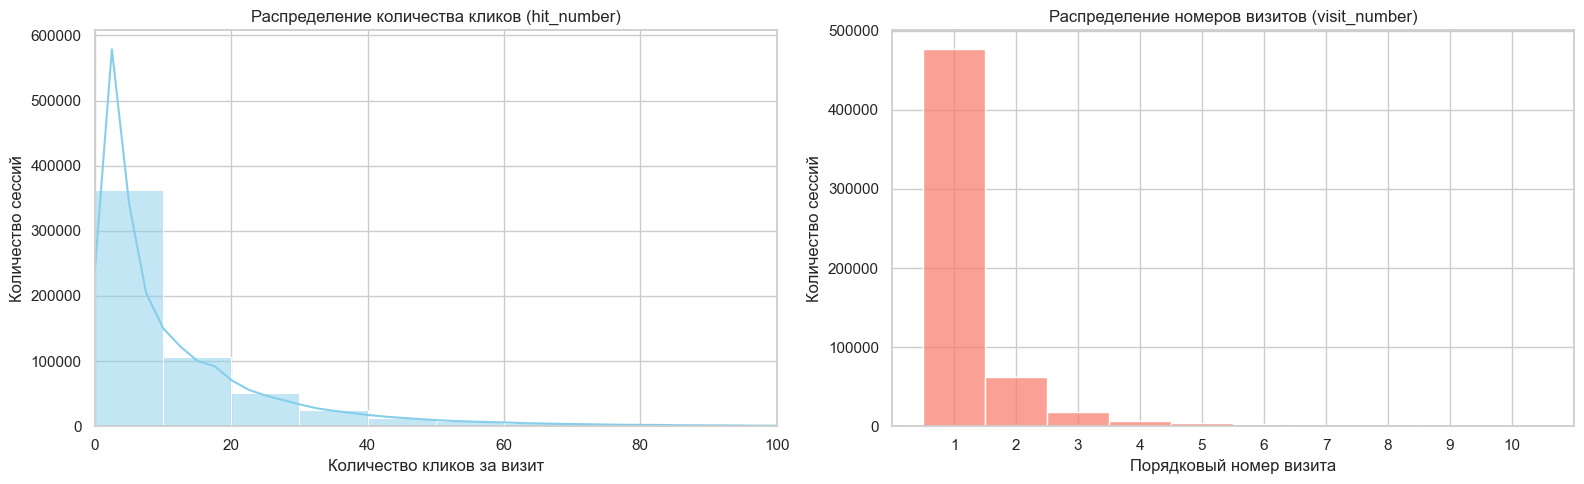

In [29]:
# Настраиваем стиль графиков
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. График для количества кликов за визит (ограничим до 100 для наглядности основного потока)
sns.histplot(data=df_merged, x='hit_number', bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение количества кликов (hit_number)')
axes[0].set_xlabel('Количество кликов за визит')
axes[0].set_ylabel('Количество сессий')
axes[0].set_xlim(0, 100) # обрезаем хвост для лучшей читаемости графика

# 2. График для порядкового номера визита
df_filtered_visits = df_merged.query("1 <= visit_number <= 10")

sns.histplot(data=df_filtered_visits, x='visit_number', 
             discrete=True, ax=axes[1], color='salmon') # discrete=True сделает столбец под каждое число

axes[1].set_title('Распределение номеров визитов (visit_number)')
axes[1].set_xlabel('Порядковый номер визита')
axes[1].set_ylabel('Количество сессий')
axes[1].set_xticks(range(1, 11)) # смотрим на самых частых посетителей

plt.tight_layout()
plt.show()

C:\Temp\ipykernel_3776\1734907012.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='is_target', y='hit_number', palette='Set2')


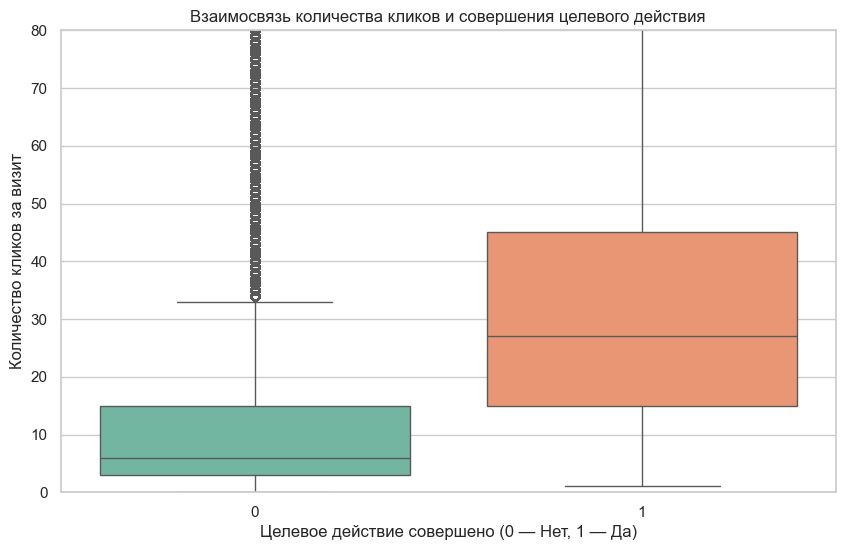

In [30]:
plt.figure(figsize=(10, 6))

# Строим boxplot, который покажет разницу в кликах между успешными и неуспешными сессиями
sns.boxplot(data=df_merged, x='is_target', y='hit_number', palette='Set2')
plt.title('Взаимосвязь количества кликов и совершения целевого действия')
plt.xlabel('Целевое действие совершено (0 — Нет, 1 — Да)')
plt.ylabel('Количество кликов за визит')
plt.ylim(0, 80) # ограничиваем шкалу Y, чтобы выбросы выше 80 не сжимали график

plt.show()

In [31]:
# Приводим дату к правильному формату и добавляем колонку
df_merged['visit_date'] = pd.to_datetime(df_sessions['visit_date'])

In [32]:
# Группируем данные по дням: считаем общее число визитов и сумму целевых действий
df_timeline = df_merged.groupby('visit_date').agg(
    total_visits=('is_target', 'count'),
    target_events=('is_target', 'sum')
).reset_index()

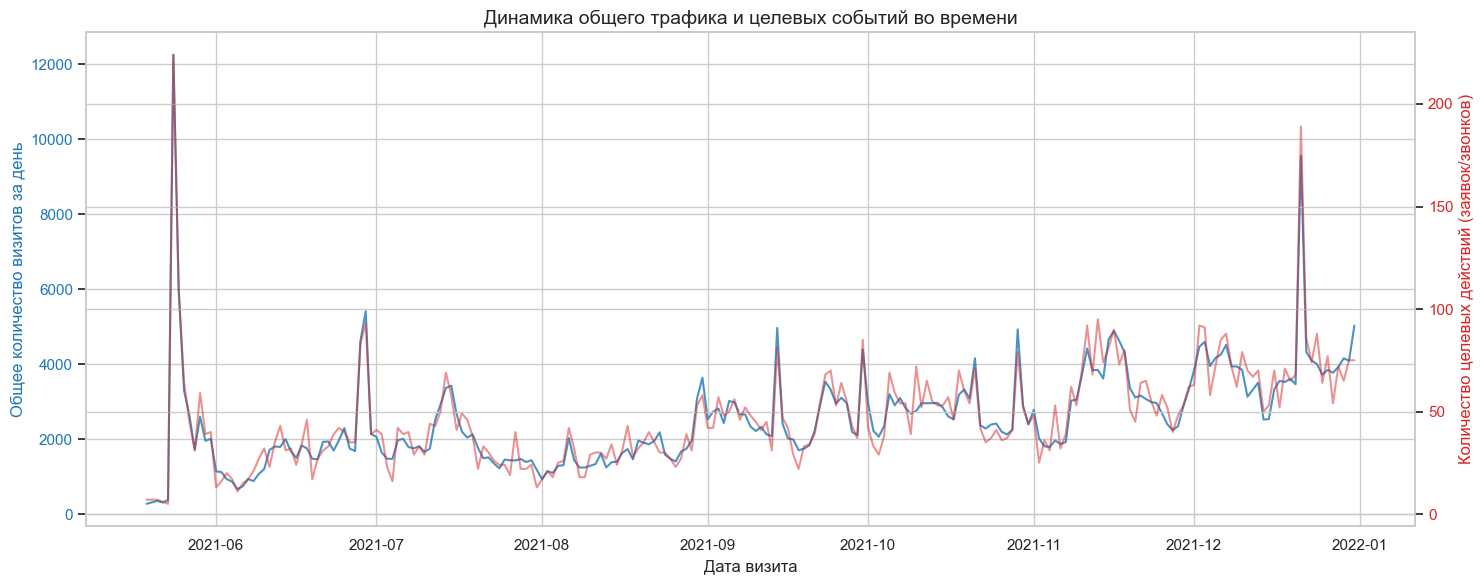

In [33]:
# Строим двухшкальный график динамики
fig, ax1 = plt.subplots(figsize=(15, 6))

# Рисуем линию общего трафика (синяя шкала слева)
color = 'tab:blue'
ax1.set_xlabel('Дата визита')
ax1.set_ylabel('Общее количество визитов за день', color=color)
sns.lineplot(data=df_timeline, x='visit_date', y='total_visits', ax=ax1, color=color, alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color)

# Создаем вторую ось Y справа для целевых действий (красная шкала)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Количество целевых действий (заявок/звонков)', color=color)
sns.lineplot(data=df_timeline, x='visit_date', y='target_events', ax=ax2, color=color, alpha=0.5)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Динамика общего трафика и целевых событий во времени', fontsize=14)
fig.tight_layout()
plt.show()

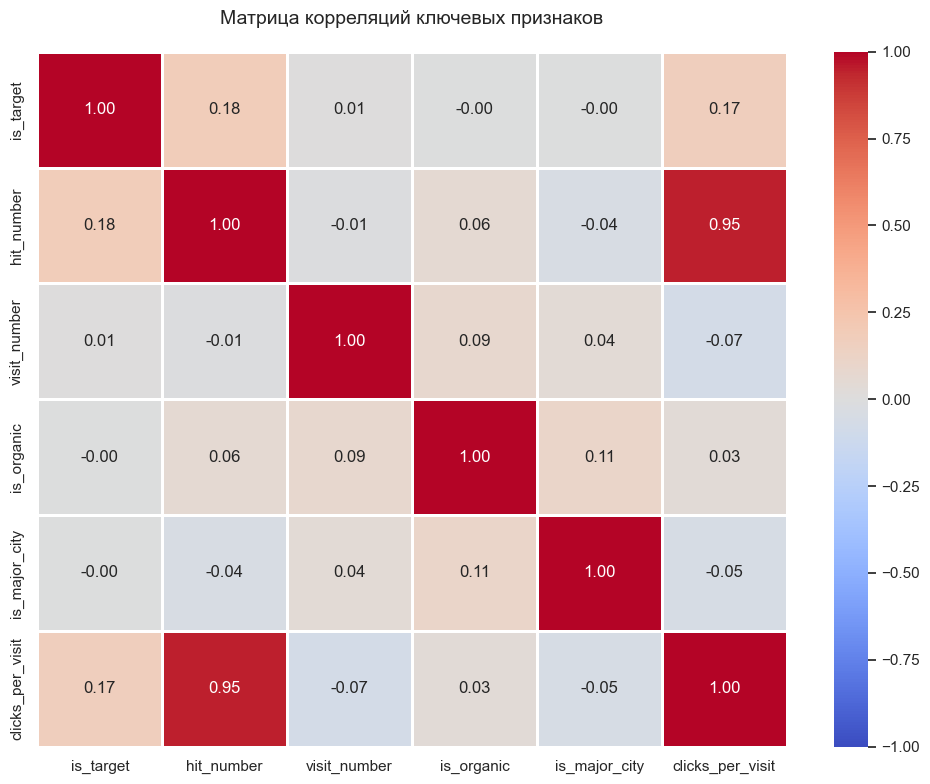

In [46]:
plt.figure(figsize=(10, 8))

# 2. Вручную отбираем только КЛЮЧЕВЫЕ фичи для корреляционного анализа
# Мы убираем весь мелкий One-Hot Encoding шум (конкретные браузеры и ОС)
core_features = [
    'is_target',        # таргет
    'hit_number',       # общее число кликов
    'visit_number',     # порядковый номер визита
    'is_organic',       # сгенерированная фича (органический трафик)
    'is_major_city',    # сгенерированная фича (крупный город)
    'clicks_per_visit'  # сгенерированная фича (плотность кликов)
]

# Проверяем, какие из этих фич точно есть в вашем датафрейме, чтобы код не упал
available_features = [col for col in core_features if col in df_merged.columns]

# 3. Считаем матрицу только для них
corr_matrix = df_merged[available_features].corr()

# 4. Строим чистый и читаемый хитмап с крупным шрифтом
sns.heatmap(corr_matrix, 
            annot=True,          # выводить цифры
            fmt=".2f",           # округление до 2 знаков
            cmap='coolwarm',     # красивая сине-красная палитра
            vmin=-1, vmax=1,     # жесткие границы шкалы от -1 до 1
            linewidths=1,        # зазоры между квадратами
            annot_kws={"size": 12}) # крупный размер шрифта для цифр

plt.title('Матрица корреляций ключевых признаков', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## Моделирование

In [35]:
# Формируем финальные признаки X и таргет y
y = df_merged['is_target']
cols_to_drop = ['visit_date', 'is_target']
X = df_merged.drop(columns=cols_to_drop, errors='ignore')

In [36]:
# Разделяем на Train/Test (80% на 20%) с сохранением баланса классов
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [41]:
# Выбираем лучшую модель
models = [
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    RandomForestClassifier(random_state=42, n_estimators=50, max_depth=10, n_jobs=-1)
]

best_score = 0.0
best_model = None

for model in models:
    score = cross_val_score(model, X, y, cv=3, scoring='roc_auc', n_jobs=-1)
    print(f'model: {type(model).__name__}, ROC-AUC mean: {score.mean():.4f}, std: {score.std():.4f}\n')

    if score.mean() > best_score:
        best_score = score.mean()
        best_model = model

model: LogisticRegression, ROC-AUC mean: 0.7842, std: 0.0030

model: RandomForestClassifier, ROC-AUC mean: 0.8517, std: 0.0012



In [42]:
# Обучаем финальную модель
best_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1,
                       random_state=42)

In [43]:
# Проверяем качество по метрике ROC-AUC
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n Итоговый ROC-AUC модели: {roc_auc:.4f}")


 Итоговый ROC-AUC модели: 0.8524


In [45]:
# Сохраняем обученную модель.
with open('sber_model.pkl', 'wb') as file:
    dill.dump(best_model, file)